# Module 05: Plug In Your Own Data

Every module so far has used datasets we created inside the notebook: synthetic arrays, small hand-typed tables, or files we wrote to disk before reading them back. This module is about connecting the tools we have built up to data you already have. The workflow is designed to require as little editing as possible: you upload your file, change two or three variable names at the top of the notebook, and the rest runs.

## Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import requests

## Workflow overview

The steps are:

1. Open the Files panel in Colab (the folder icon on the left sidebar).
2. Navigate into the `data/` folder, or create it if it does not exist yet (see Module 00).
3. Upload your CSV or Excel file into that folder by clicking the upload icon.
4. Edit the **Configuration** cell below: set `FILE_PATH` to match your filename, and set `X_COLUMN` and `Y_COLUMN` to match the column headers in your file exactly, including capitalization.
5. Run all cells from top to bottom.

That is the entire workflow. The cells below detect the file format automatically, load the data, and produce a styled plot. The optional variables `Y2_COLUMN` and `Y_ERROR_COLUMN` can be left as `None` if you do not need them.

## Configuration

This is the only cell you need to edit. Everything else adapts to what you set here.

In [2]:
# ── FILE ──────────────────────────────────────────────────────────────────────
# Path to your data file, relative to the notebook.
# Examples:
#   'data/my_experiment.csv'
#   'data/results_run3.xlsx'
FILE_PATH = 'data/sample_viscosity.csv'   # <-- replace with your filename

# ── COLUMNS ───────────────────────────────────────────────────────────────────
# The exact column header for your x axis (must match the spreadsheet header).
X_COLUMN  = 'Temperature_C'               # <-- replace with your x column name

# The exact column header for your primary y axis.
Y_COLUMN  = 'Viscosity_mPas'              # <-- replace with your y column name

# A second y column to overlay on the same plot. Set to None to skip.
Y2_COLUMN = None                          # e.g. 'Viscosity_repeat' or None

# A column containing the error (standard deviation or standard error) for Y.
# Set to None to skip error bars.
Y_ERROR_COLUMN = None                     # e.g. 'Viscosity_std' or None

# ── AXIS LABELS ───────────────────────────────────────────────────────────────
# By default the axis labels are taken from the column names.
# Override them here if you want units or a cleaner label.
X_LABEL = 'Temperature (°C)'             # <-- or set to None to use X_COLUMN
Y_LABEL = 'Viscosity (mPa·s)'            # <-- or set to None to use Y_COLUMN

## Load the data

The cell below reads the file and adapts to its format automatically. CSV and Excel files are handled differently by pandas, but the result in both cases is the same object: a DataFrame with named columns.

In [3]:
# Detect format from the file extension
_, ext = os.path.splitext(FILE_PATH)
ext = ext.lower()

if ext == '.csv':
    df = pd.read_csv(FILE_PATH)
elif ext in ('.xlsx', '.xls'):
    df = pd.read_excel(FILE_PATH)
else:
    raise ValueError(f'Unsupported file format: {ext}. Use .csv, .xlsx, or .xls.')

print(f'Loaded {len(df)} rows from {FILE_PATH}')
print(f'Columns: {list(df.columns)}')

Loaded 15 rows from data/sample_viscosity.csv
Columns: ['Temperature_C', 'Viscosity_mPas']


In [4]:
df.head()  # Preview the first five rows to confirm the data loaded correctly

,Temperature_C,Viscosity_mPas
0,10,142.3
1,15,118.7
2,20,98.4
3,25,81.2
4,30,67.5


Check that the column names in the output above match what you entered in the Configuration cell. If a column name has a trailing space or a different capitalization, pandas will raise a `KeyError` in the next cell. The `list(df.columns)` printout above shows the exact strings pandas sees.

## Plot

The cell below builds the figure from the configuration variables. Axis labels fall back to the column names if you left `X_LABEL` or `Y_LABEL` as `None`. The optional second series and error bars are included only when the corresponding configuration variables are set.

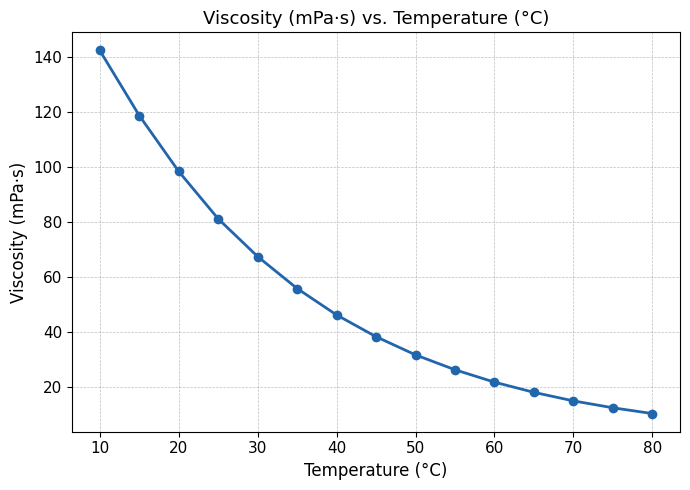

In [5]:
# Resolve axis labels: use the override if provided, otherwise fall back to column name
x_label = X_LABEL if X_LABEL is not None else X_COLUMN
y_label = Y_LABEL if Y_LABEL is not None else Y_COLUMN

fig, ax = plt.subplots(figsize=(7, 5))

# Primary series
if Y_ERROR_COLUMN is not None:
    # Plot with error bars when an error column is configured
    ax.errorbar(
        df[X_COLUMN], df[Y_COLUMN],
        yerr=df[Y_ERROR_COLUMN],
        fmt='o-',              # circle markers connected by a line
        color='#2166ac',
        linewidth=1.8,
        markersize=6,
        capsize=4,             # horizontal caps on the error bars
        capthick=1.2,
        elinewidth=1.0,
        label=Y_COLUMN
    )
else:
    ax.plot(
        df[X_COLUMN], df[Y_COLUMN],
        color='#2166ac',
        linewidth=2,
        marker='o',
        markersize=6,
        label=Y_COLUMN
    )

# Optional second series
if Y2_COLUMN is not None:
    ax.plot(
        df[X_COLUMN], df[Y2_COLUMN],
        color='#d6604d',
        linewidth=2,
        marker='s',
        markersize=6,
        label=Y2_COLUMN
    )

# Labels and styling
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel(y_label, fontsize=12)
ax.set_title(f'{y_label} vs. {x_label}', fontsize=13)
ax.tick_params(labelsize=11)
ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

# Show legend only when there are multiple series or error bars with a label
if Y2_COLUMN is not None or Y_ERROR_COLUMN is not None:
    ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

## Demonstrating error bars

To show how error bars look, the cell below creates a small example dataset with a measurement uncertainty column, then reruns the plot logic with that column configured. In your own workflow you would set `Y_ERROR_COLUMN` in the Configuration cell rather than running this demonstration.

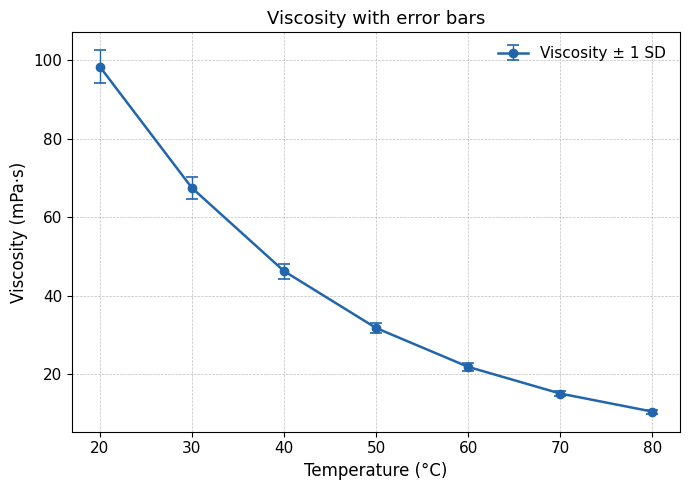

In [6]:
# Synthetic demonstration: viscosity measurements with estimated uncertainties
demo_df = pd.DataFrame({
    'Temperature_C':  [20, 30, 40, 50, 60, 70, 80],
    'Viscosity_mPas': [98.4, 67.5, 46.3, 31.8, 21.9, 15.1, 10.5],
    'Viscosity_std':  [4.1,  2.8,  1.9,  1.4,  1.0,  0.7,  0.5],
})

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    demo_df['Temperature_C'],
    demo_df['Viscosity_mPas'],
    yerr=demo_df['Viscosity_std'],
    fmt='o-',
    color='#2166ac',
    linewidth=1.8,
    markersize=6,
    capsize=4,
    capthick=1.2,
    elinewidth=1.0,
    label='Viscosity ± 1 SD'
)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Viscosity (mPa·s)', fontsize=12)
ax.set_title('Viscosity with error bars', fontsize=13)
ax.tick_params(labelsize=11)
ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

The `capsize` argument sets the width of the horizontal caps at the end of each error bar in points. The `elinewidth` argument controls the thickness of the vertical error bar lines independently from the main line width. These two parameters together determine how prominent the error bars appear relative to the data series.

## Preparing your Excel or CSV file for this workflow

Most data files that come out of instruments or lab software load without issue, but a few common formatting habits cause problems that are worth knowing about before you encounter them.

**Column headers.** Put your column names in the first row, with no blank rows above them. pandas reads the first row as headers by default. If your file has a title row or instrument metadata above the headers, use the `skiprows` argument: `pd.read_excel('file.xlsx', skiprows=3)` skips the first three rows before reading headers.

**One header row, not two.** Some people use two rows to separate the quantity name from the units, for example "Temperature" in row 1 and "°C" in row 2. pandas reads row 1 as headers and row 2 as data, so the units row becomes a string value in the first data row and the column dtype becomes object rather than float. The cleanest solution is a single header row with the unit in the name: `Temperature_C` or `Temperature (°C)`.

**No merged cells.** Merged cells in Excel cause pandas to read `NaN` in all but the first cell of the merged region. Unmerge everything before loading.

**One sheet of data per file.** If you have multiple experimental runs in separate sheets, load each one explicitly with `sheet_name='Run1'`. The default (`sheet_name=0`) loads only the first sheet.

**Consistent data types within each column.** A column of numbers that contains one text entry (such as `'N/A'` or `'above range'`) will be read as an object column, and all arithmetic on it will fail. Replace non-numeric entries with a proper missing-value marker: leave the cell blank, or use `NaN` explicitly. pandas treats blank cells as `NaN` automatically.